# Notebook 01 — UCI HAR Dataset Exploration

Mirrors the structure of `01_explore_datasets.ipynb` (whuGAIT) for the UCI HAR dataset.

## Dataset structure

- **30 subjects**, pre-split by the dataset authors into 21 train / 9 test (subjects are **disjoint** across splits).
- Windows: 128 timesteps, 50% overlap, already segmented.
- Channels used: `body_acc_{x,y,z}` + `body_gyro_{x,y,z}` (6 channels, matching whuGAIT).

## Pipeline mapping

```
UCI HAR train split  (21 subjects)  → Members   → NB02 CNN + NB03 Auth training
UCI HAR test split   ( 9 subjects)  → Non-members → NB04/05 MIA attack
```

Auth pairs are built synthetically by `pair_builder.build_auth_pairs` (random balanced sampling).
There is no pre-built pair file equivalent to Dataset #5.

In [ ]:
%load_ext autoreload
%autoreload 2


In [ ]:
import sys
sys.path.insert(0, '..')

import json
import logging
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from src.data.ucihar_dataset import load_ucihar
from src.data.pair_builder import build_auth_pairs
from src.utils.config_loader import get_dataset
from src.utils.latex_writer import write_latex_metrics

# ── config ──
DATASET   = get_dataset()  # should be 'ucihar' when this notebook runs
DATA_ROOT = Path('../data')
LOG_DIR   = Path('../logs') / DATASET
ARTIFACT_DIR = Path('../artifacts') / DATASET
LOG_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

UCI_ROOT = DATA_ROOT / 'UCI HAR Dataset'

logging.basicConfig(level=logging.INFO, format='%(message)s')
log = logging.getLogger('nb01_ucihar')
log.info(f'Active dataset: {DATASET}')

## 1. Load windows

In [10]:
X_train, y_train = load_ucihar(str(UCI_ROOT), 'train', gait_only=True)
X_test,  y_test  = load_ucihar(str(UCI_ROOT), 'test',  gait_only=True)

train_subjects = sorted(np.unique(y_train).tolist())
test_subjects  = sorted(np.unique(y_test).tolist())
all_subjects   = sorted(set(train_subjects) | set(test_subjects))

log.info(f'Train: {len(y_train)} windows, {len(train_subjects)} subjects')
log.info(f'Test:  {len(y_test)} windows, {len(test_subjects)} subjects')
log.info(f'Total subjects: {len(all_subjects)}')

# sanity: train/test subjects must be disjoint
overlap = set(train_subjects) & set(test_subjects)
assert len(overlap) == 0, f'Train/test subject overlap: {overlap}'
log.info('Train/test subject split is clean (no overlap)')

Train: 3285 windows, 21 subjects
Test:  1387 windows, 9 subjects
Total subjects: 30
Train/test subject split is clean (no overlap)


## 2. Member / non-member split

Train subjects → **members** (used to train CNN + authenticator).  
Test subjects → **non-members** (held out for MIA and evasion evaluation).

In [ ]:
member_ids     = train_subjects
nonmember_ids  = test_subjects

log.info(f'Members     ({len(member_ids)}): {member_ids}')
log.info(f'Non-members ({len(nonmember_ids)}): {nonmember_ids}')

split = {
    'dataset':        'ucihar',
    'train_ids':      member_ids,
    'held_out_ids':   nonmember_ids,
    'n_train':        len(member_ids),
    'n_held_out':     len(nonmember_ids),
}
with open(ARTIFACT_DIR / 'subject_split.json', 'w') as f:
    json.dump(split, f, indent=2)
log.info(f'Saved: {ARTIFACT_DIR}/subject_split.json')

## 3. Window count per subject

Train windows/subject — min: 124, max: 197, mean: 156


Test  windows/subject — min: 138, max: 172, mean: 154


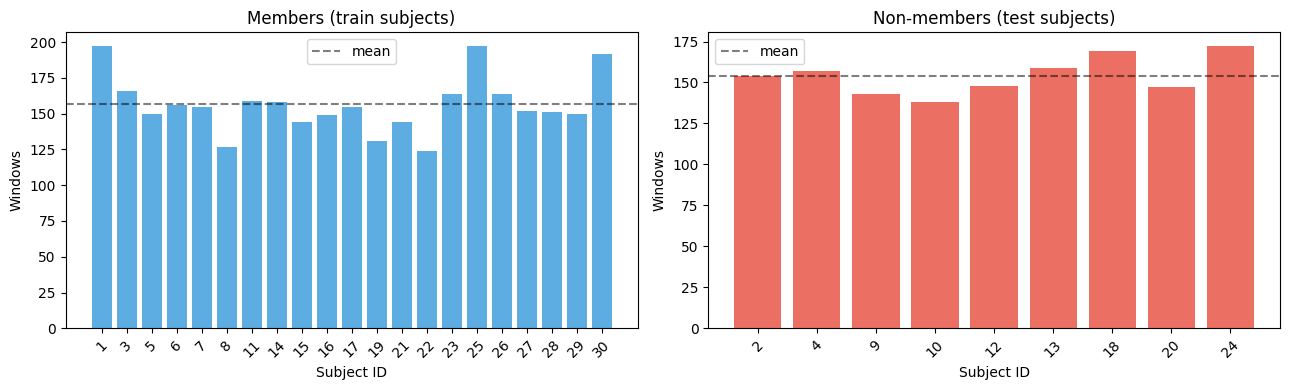

In [12]:
counts_train = {s: int((y_train == s).sum()) for s in train_subjects}
counts_test  = {s: int((y_test  == s).sum()) for s in test_subjects}

log.info(f'Train windows/subject — min: {min(counts_train.values())}, '
         f'max: {max(counts_train.values())}, '
         f'mean: {np.mean(list(counts_train.values())):.0f}')
log.info(f'Test  windows/subject — min: {min(counts_test.values())}, '
         f'max: {max(counts_test.values())}, '
         f'mean: {np.mean(list(counts_test.values())):.0f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, counts, title, color in [
    (axes[0], counts_train, 'Members (train subjects)', '#3498db'),
    (axes[1], counts_test,  'Non-members (test subjects)', '#e74c3c'),
]:
    sids = list(counts.keys())
    vals = list(counts.values())
    ax.bar(range(len(sids)), vals, color=color, alpha=0.8)
    ax.set_xticks(range(len(sids)))
    ax.set_xticklabels(sids, rotation=45)
    ax.set_xlabel('Subject ID')
    ax.set_ylabel('Windows')
    ax.set_title(title)
    ax.axhline(np.mean(vals), ls='--', color='black', alpha=0.5, label='mean')
    ax.legend()

plt.tight_layout()
plt.show()

## 4. Signal statistics

Per-channel mean and standard deviation across all train windows. Used to check that the 6 channels are in a reasonable range and that body_acc / body_gyro have different scales.

In [13]:
channel_names = ['body_acc_x', 'body_acc_y', 'body_acc_z',
                 'body_gyro_x', 'body_gyro_y', 'body_gyro_z']

ch_mean = X_train.mean(axis=(0, 2))   # (6,)
ch_std  = X_train.std(axis=(0, 2))    # (6,)

for name, m, s in zip(channel_names, ch_mean, ch_std):
    log.info(f'  {name:15s}  mean={m:+.4f}  std={s:.4f}')

  body_acc_x       mean=-0.0005  std=0.2903
  body_acc_y       mean=-0.0016  std=0.1789
  body_acc_z       mean=-0.0011  std=0.1558
  body_gyro_x      mean=-0.0002  std=0.6024
  body_gyro_y      mean=-0.0003  std=0.5674
  body_gyro_z      mean=-0.0047  std=0.3761


## 5. Build authentication pairs

Since UCI HAR has no pre-built pair file (unlike Dataset #5), pairs are built synthetically:
- **Train pairs** (members): both windows from the train split; used to train the authenticator.
- **Test pairs** (non-members): both windows from the test split; used for MIA / evasion evaluation.

Label convention matches Dataset #5: `y=0` = same person, `y=1` = different person.

In [ ]:
N_TRAIN_PAIRS = 30000   # per class → 60k total pairs for authenticator training
N_TEST_PAIRS  =  5000   # per class → 10k total pairs for attack evaluation

X1_tr, X2_tr, y_tr, subj1_tr, subj2_tr = build_auth_pairs(
    X_train, y_train, n_pairs_per_class=N_TRAIN_PAIRS, seed=42)
X1_te, X2_te, y_te, subj1_te, subj2_te = build_auth_pairs(
    X_test,  y_test,  n_pairs_per_class=N_TEST_PAIRS,  seed=42)

log.info(f'Train pairs: {len(y_tr)} total  (same={int((y_tr==0).sum())}, diff={int((y_tr==1).sum())})')
log.info(f'Test  pairs: {len(y_te)} total  (same={int((y_te==0).sum())}, diff={int((y_te==1).sum())})')

# Verify no contamination: member subjects only in train pairs, non-member in test pairs
member_set    = set(member_ids)
nonmember_set = set(nonmember_ids)
assert set(subj1_tr.tolist() + subj2_tr.tolist()) <= member_set,    "Train pairs contain non-member subjects!"
assert set(subj1_te.tolist() + subj2_te.tolist()) <= nonmember_set, "Test pairs contain member subjects!"
log.info('Contamination check passed')

# Pairs per member subject
pairs_per_member = {s: int((subj1_tr == s).sum() + (subj2_tr == s).sum()) for s in member_ids}
log.info(f'Pairs/member — min={min(pairs_per_member.values())}, max={max(pairs_per_member.values())}, '         f'mean={sum(pairs_per_member.values())/len(pairs_per_member):.0f}')

# Save — same file, now includes subj1/subj2 attribution so NB04/05 do not need fingerprinting
np.savez_compressed(
    ARTIFACT_DIR / 'auth_pairs.npz',
    X1_tr=X1_tr,    X2_tr=X2_tr,    y_tr=y_tr,
    subj1_tr=subj1_tr, subj2_tr=subj2_tr,
    X1_te=X1_te,    X2_te=X2_te,    y_te=y_te,
    subj1_te=subj1_te, subj2_te=subj2_te,
)
log.info(f'Saved: {ARTIFACT_DIR}/auth_pairs.npz')


## 6. Intra-pair correlation

Sanity check that same-person pairs and different-person pairs have different correlation profiles. For whuGAIT Dataset #5 the correlation structure was inverted (same-person pairs were anti-correlated); here we verify whether UCI HAR behaves more intuitively.

Same-person pair correlation: mean=0.005  std=0.180
Diff-person pair correlation: mean=-0.003  std=0.134


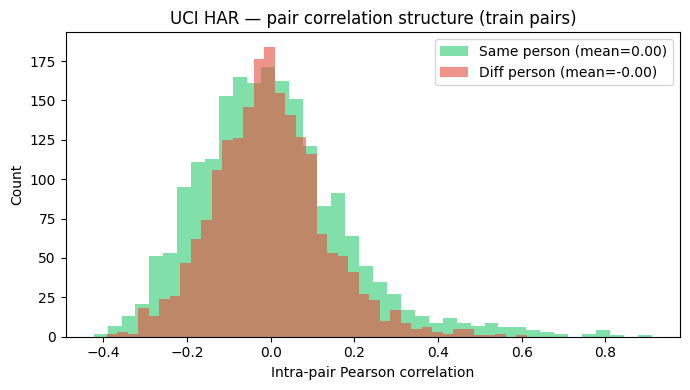

In [15]:
def pair_corr(X1, X2):
    """Mean Pearson correlation across channels and batch."""
    corrs = []
    for i in range(len(X1)):
        ch_corrs = [
            float(np.corrcoef(X1[i, c], X2[i, c])[0, 1])
            for c in range(X1.shape[1])
        ]
        corrs.append(np.mean(ch_corrs))
    return np.array(corrs)

sample = 2000
same_mask = y_tr == 0
diff_mask = y_tr == 1

corr_same = pair_corr(X1_tr[same_mask][:sample], X2_tr[same_mask][:sample])
corr_diff = pair_corr(X1_tr[diff_mask][:sample], X2_tr[diff_mask][:sample])

log.info(f'Same-person pair correlation: mean={corr_same.mean():.3f}  std={corr_same.std():.3f}')
log.info(f'Diff-person pair correlation: mean={corr_diff.mean():.3f}  std={corr_diff.std():.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(corr_same, bins=40, alpha=0.6, color='#2ecc71', label=f'Same person (mean={corr_same.mean():.2f})')
ax.hist(corr_diff, bins=40, alpha=0.6, color='#e74c3c', label=f'Diff person (mean={corr_diff.mean():.2f})')
ax.set_xlabel('Intra-pair Pearson correlation')
ax.set_ylabel('Count')
ax.set_title('UCI HAR — pair correlation structure (train pairs)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Write LaTeX metrics

In [16]:
write_latex_metrics('nb01_ucihar', {
    'uciharTotalSubjects':  len(all_subjects),
    'uciharMemberSubjects': len(member_ids),
    'uciharNonmemberSubjects': len(nonmember_ids),
    'uciharTrainWindows':   len(y_train),
    'uciharTestWindows':    len(y_test),
    'uciharTrainPairs':     len(y_tr),
    'uciharTestPairs':      len(y_te),
}, output_dir='../latex/generated', log=log)

LaTeX metrics written: ../latex/generated/nb01_ucihar_metrics.tex
